# 01. Datos, limpieza y EDA del corpus IPS

Este notebook concentra la preparación inicial y el análisis exploratorio descriptivo del corpus IPS. El flujo queda organizado como una auditoría reproducible y autocontenida: no invoca scripts externos para producir el EDA.

**Objetivo:** documentar el estado del corpus, la limpieza aplicada, el universo `dataset_denoised`, la comparabilidad de los subconjuntos usados en el proyecto y las limitaciones de metadata disponibles.

**Reglas de seguridad:** no se imprimen textos clínicos crudos, nombres de pacientes ni identificadores originales. Las salidas públicas son agregadas.

## 0. Alcance metodológico

Este notebook cubre tres decisiones descriptivas:

1. Validar la carga de `ips_raw.csv` y reproducir la limpieza inicial sin sobrescribir artefactos canónicos si difieren.
2. Confirmar el universo modelado: `dataset_denoised`.
3. Comparar los subconjuntos del proyecto: conjunto de entrenamiento, conjunto de validación y conjunto de prueba.

El EDA es descriptivo. No reentrena modelos, no cambia etiquetas, no modifica particiones y no redefine la ontología clínica.


## 1. Configuración y utilidades

Se importan librerías, rutas del proyecto y funciones auxiliares. Esta celda también fija opciones de visualización para que las tablas sean legibles dentro del notebook.

In [1]:
import json
import re
import sys
import unicodedata
from collections import Counter
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Utilidades compartidas del repositorio.
sys.path.insert(0, str(Path.cwd().resolve()))
from utils_shared import setup_paths, validate_file_exists, guess_text_col, guess_label_col, normalize_label

# Configuración visual y de pandas.
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 120)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (10, 5)})

paths = setup_paths()
BASE_PATH = paths['BASE_PATH']
DATA_PATH = paths['DATA_PATH']
REPORTS_PATH = BASE_PATH / 'reports'
SPLITS_PATH = DATA_PATH / 'splits'
EDA_AUDIT_DIR = REPORTS_PATH / 'eda_audit_20260619'
TABLES_DIR = EDA_AUDIT_DIR / 'tables'
FIGURES_DIR = EDA_AUDIT_DIR / 'figures'
PRIVATE_DIR = EDA_AUDIT_DIR / 'private'

for directory in [EDA_AUDIT_DIR, TABLES_DIR, FIGURES_DIR, PRIVATE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

RAW_FILE = DATA_PATH / 'ips_raw.csv'
CHECKPOINT = DATA_PATH / 'checkpoints' / 'roberta_clinical' / 'checkpoint-210'
MAX_TOKENS = 512

SUBSET_ORDER = ['train', 'dev', 'test']
SUBSET_LABELS = {
    'train': 'conjunto de entrenamiento',
    'dev': 'conjunto de validacion',
    'test': 'conjunto de prueba',
}
SUBSET_DISPLAY_ORDER = [SUBSET_LABELS[k] for k in SUBSET_ORDER]

print('Configuración lista.')
print(f'Raíz del proyecto: {BASE_PATH}')
print(f'Directorio de salida EDA: {EDA_AUDIT_DIR}')

Configuración lista.
Raíz del proyecto: /Users/manuelnunez/Projects/psych-phenotyping-paraguay
Directorio de salida EDA: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/reports/eda_audit_20260619


## 2. Funciones auxiliares del EDA

Las funciones están agrupadas al inicio para que el resto del notebook lea como una secuencia de análisis. Incluyen formateo, resúmenes numéricos, normalización de texto, tokenización y generación de tablas Markdown.

In [2]:
SPANISH_STOPWORDS_EDA = {
    'a', 'al', 'ante', 'antes', 'como', 'con', 'contra', 'cuando', 'de', 'del', 'desde',
    'donde', 'e', 'el', 'ella', 'ellas', 'ellos', 'en', 'entre', 'es', 'esa', 'ese',
    'esta', 'este', 'fue', 'ha', 'hay', 'la', 'las', 'le', 'les', 'lo', 'los', 'mas',
    'me', 'mi', 'muy', 'no', 'nos', 'o', 'otra', 'otro', 'para', 'pero', 'por',
    'porque', 'que', 'se', 'sin', 'sobre', 'su', 'sus', 'tambien', 'un', 'una', 'uno',
    'y', 'ya', 'paciente', 'consulta', 'control', 'refiere', 'indica', 'tratamiento',
}

_RE_MULTI = re.compile(r'(.)\1{2,}')
START_TEMPLATE_RE = re.compile(r'(?is)\b2\)\s*examen\s+fisico\s+gral\.?(?:\s+y\s+ginecologico)?')
END_TEMPLATE_RE = re.compile(r'(?is)\bpaciente\s*:\s*[0-9]+')


def fmt_es(value, digits=2):
    """Formatea números con separador decimal en coma para el reporte."""
    if value is None:
        return 'No disponible'
    try:
        if pd.isna(value):
            return 'No disponible'
        value = float(value)
    except Exception:
        return str(value)
    if abs(value - round(value)) < 1e-9:
        return f'{int(round(value)):,}'.replace(',', '.')
    return f'{value:,.{digits}f}'.replace(',', 'X').replace('.', ',').replace('X', '.')


def pct_es(value, digits=2):
    return f'{fmt_es(value, digits)}%'


def md_table(headers, rows):
    lines = ['| ' + ' | '.join(headers) + ' |']
    lines.append('| ' + ' | '.join(['---'] * len(headers)) + ' |')
    for row in rows:
        lines.append('| ' + ' | '.join(str(x).replace('\n', ' ') for x in row) + ' |')
    return '\n'.join(lines)


def summarize_numeric(series):
    x = pd.to_numeric(series, errors='coerce').dropna()
    if x.empty:
        return {k: np.nan for k in [
            'media', 'desviacion_estandar', 'mediana', 'minimo', 'maximo',
            'percentil_75', 'percentil_95', 'percentil_99',
        ]}
    return {
        'media': float(x.mean()),
        'desviacion_estandar': float(x.std(ddof=1)) if len(x) > 1 else 0.0,
        'mediana': float(x.median()),
        'minimo': float(x.min()),
        'maximo': float(x.max()),
        'percentil_75': float(x.quantile(0.75)),
        'percentil_95': float(x.quantile(0.95)),
        'percentil_99': float(x.quantile(0.99)),
    }


def normalize_sex(value):
    text = '' if pd.isna(value) else str(value).strip().lower()
    if text.startswith('f') or 'mujer' in text or 'femen' in text:
        return 'mujer'
    if text.startswith('m') or 'hombre' in text or 'masc' in text:
        return 'hombre'
    return 'faltante_o_no_informado'


def clean_text_eda(value):
    """Normalización conservadora usada para reproducir `ips_clean` sin exponer texto."""
    if pd.isna(value):
        return ''
    text = str(value).strip()
    text = unicodedata.normalize('NFC', text)
    text = _RE_MULTI.sub(r'\1\1', text)
    text = re.sub(r'[^0-9A-Za-zÁÉÍÓÚÜÑáéíóúüñ \t\n\r.,;:!?()\-/%+]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def remove_duplicate_sentences(text):
    if pd.isna(text) or not str(text).strip():
        return ''
    seen = set()
    unique_sentences = []
    for sentence in str(text).split('. '):
        clean_sentence = sentence.strip()
        if clean_sentence and clean_sentence not in seen:
            seen.add(clean_sentence)
            unique_sentences.append(sentence)
    return '. '.join(unique_sentences)


def strip_ips_template_block(text):
    """Retira el bloque administrativo/formulario IPS sin tocar el texto previo ni posterior."""
    if text is None:
        return ''
    text = str(text)
    start = START_TEMPLATE_RE.search(text)
    if not start:
        return text
    end = END_TEMPLATE_RE.search(text, pos=start.start())
    if not end:
        return text[:start.start()].strip()
    cleaned = (text[:start.start()] + ' ' + text[end.end():]).strip()
    return re.sub(r'\s{2,}', ' ', cleaned)


def tokenize_words_for_vocab(text):
    raw = '' if pd.isna(text) else str(text).lower()
    tokens = re.findall(r'[a-záéíóúüñ]+', raw)
    return [t for t in tokens if len(t) >= 3 and t not in SPANISH_STOPWORDS_EDA]


def subset_row_order(frame, column='subconjunto'):
    order = {name: idx for idx, name in enumerate(SUBSET_DISPLAY_ORDER)}
    out = frame.copy()
    out['_orden_subconjunto'] = out[column].map(order)
    return out.sort_values('_orden_subconjunto').drop(columns='_orden_subconjunto')


print('Funciones auxiliares listas.')

Funciones auxiliares listas.


## 3. Carga del raw y auditoría de esquema

Se carga `ips_raw.csv` y se detectan columnas críticas: texto clínico, etiqueta diagnóstica y paciente. La salida es un diccionario de datos agregado; no se muestran filas ni fragmentos clínicos.

In [3]:
validate_file_exists(RAW_FILE, 'Error: falta `ips_raw.csv` en la carpeta `data`.')
df_raw = pd.read_csv(RAW_FILE)

text_col = guess_text_col(df_raw)
label_col_raw = guess_label_col(df_raw)
patient_col = next((c for c in ['patient_id', 'id_paciente', 'paciente', 'Prontuario'] if c in df_raw.columns), None)

if patient_col is None:
    raise ValueError('No se encontró una columna de paciente compatible.')

schema_raw = pd.DataFrame({
    'columna': df_raw.columns,
    'tipo': [str(df_raw[c].dtype) for c in df_raw.columns],
    'valores_nulos': [int(df_raw[c].isna().sum()) for c in df_raw.columns],
    'valores_unicos': [int(df_raw[c].nunique(dropna=True)) for c in df_raw.columns],
})

print(f'Raw cargado: {len(df_raw)} notas y {df_raw.shape[1]} columnas.')
print(f'Columna de texto clínico: {text_col}')
print(f'Columna de etiqueta original: {label_col_raw}')
print(f'Columna de paciente: {patient_col}')
display(schema_raw)

Raw cargado: 3155 notas y 10 columnas.
Columna de texto clínico: Motivo Consulta
Columna de etiqueta original: Tipo
Columna de paciente: Prontuario


,columna,tipo,valores_nulos,valores_unicos
0,Archivo,object,0,90
1,Prontuario,int64,0,90
2,Nombre Paciente,object,0,90
3,Sexo,object,0,3
4,Fecha Nacimiento,object,0,87
5,N° Consulta,int64,0,65
6,Id,int64,0,90
7,Fecha Consulta,object,0,1134
8,Motivo Consulta,object,7,3126
9,Tipo,object,0,2


## 4. Limpieza inicial reproducible

La limpieza de esta etapa es deliberadamente conservadora. Normaliza caracteres, remueve duplicados exactos por consulta y retira bloques de plantilla IPS. El objetivo es reproducir el archivo limpio histórico sin reemplazarlo automáticamente si difiere.

In [4]:
df_work = df_raw.copy()
df_work['etiqueta'] = df_work[label_col_raw].apply(normalize_label)
df_work['text_clean'] = df_work[text_col].apply(clean_text_eda)
df_work['text_dedup'] = df_work['text_clean'].apply(remove_duplicate_sentences)

initial_rows = len(df_work)
duplicate_subset = [patient_col, 'Fecha Consulta', 'text_dedup'] if 'Fecha Consulta' in df_work.columns else [patient_col, 'text_dedup']
df_clean = df_work.drop_duplicates(subset=duplicate_subset).copy()
removed_duplicate_rows = initial_rows - len(df_clean)

df_clean['feat_had_template_block'] = df_clean['text_dedup'].astype(str).str.contains(START_TEMPLATE_RE, regex=True).astype(int)
df_clean['texto'] = df_clean['text_dedup'].astype(str).apply(strip_ips_template_block)

cleaning_summary = pd.DataFrame([
    {'indicador': 'filas raw originales', 'valor': int(initial_rows)},
    {'indicador': 'filas eliminadas por duplicado exacto', 'valor': int(removed_duplicate_rows)},
    {'indicador': 'filas limpias resultantes', 'valor': int(len(df_clean))},
    {'indicador': 'notas con bloque plantilla detectado', 'valor': int(df_clean['feat_had_template_block'].sum())},
    {'indicador': 'porcentaje con bloque plantilla detectado', 'valor': float(df_clean['feat_had_template_block'].mean() * 100)},
])

chars_before = df_clean['text_dedup'].astype(str).str.len().sum()
chars_after = df_clean['texto'].astype(str).str.len().sum()
cleaning_summary.loc[len(cleaning_summary)] = {
    'indicador': 'reduccion porcentual de caracteres por retiro de plantilla',
    'valor': float(100 * (1 - chars_after / (chars_before + 1e-9))),
}

display(cleaning_summary)

,indicador,valor
0,filas raw originales,3155.000000
1,filas eliminadas por duplicado exacto,12.000000
2,filas limpias resultantes,3143.000000
3,notas con bloque plantilla detectado,2521.000000
4,porcentaje con bloque plantilla detectado,80.209990
5,reduccion porcentual de caracteres por retiro de plantilla,28.291993


## 5. Exportación no destructiva de `ips_clean`

El notebook no reemplaza `ips_clean.csv` si el archivo existente no coincide exactamente con la reproducción local. En ese caso deja un candidato privado para revisión manual.

In [5]:
out_file = DATA_PATH / 'ips_clean.csv'
columns_to_keep = [c for c in [patient_col, 'etiqueta', 'texto', 'feat_had_template_block'] if c in df_clean.columns]
df_export = df_clean[columns_to_keep].rename(columns={patient_col: 'patient_id'})

if out_file.exists():
    df_existing = pd.read_csv(out_file)
    same_shape = df_existing.shape == df_export.shape
    same_columns = list(df_existing.columns) == list(df_export.columns)
    same_values = same_shape and same_columns and df_existing.fillna('').astype(str).equals(df_export.fillna('').astype(str))
    if same_values:
        print('`ips_clean.csv` ya existe y coincide; no se sobrescribe.')
    else:
        candidate_path = PRIVATE_DIR / 'ips_clean_candidate_no_versionar.csv'
        df_export.to_csv(candidate_path, index=False)
        print('`ips_clean.csv` existe y difiere; no se sobrescribe.')
        print(f'Candidato privado generado en: {candidate_path.relative_to(BASE_PATH)}')
else:
    df_export.to_csv(out_file, index=False)
    print('`ips_clean.csv` no existía; se escribió el archivo limpio inicial.')

`ips_clean.csv` existe y difiere; no se sobrescribe.
Candidato privado generado en: reports/eda_audit_20260619/private/ips_clean_candidate_no_versionar.csv


## 6. Carga de artefactos canónicos del pipeline

A partir de aquí el EDA principal se calcula sobre artefactos ya definidos por el pipeline. El texto, etiqueta, elegibilidad y subconjunto provienen de esos artefactos, no de una reconstrucción difusa desde raw.

In [6]:
required_files = {
    'dataset_base': SPLITS_PATH / 'dataset_base.csv',
    'dataset_denoised': DATA_PATH / 'dataset_denoised.csv',
    'clinical_signal': DATA_PATH / 'dataset_with_clinical_signal_flag.csv',
    'train_denoised': SPLITS_PATH / 'train_denoised.csv',
    'dev_denoised': SPLITS_PATH / 'dev_denoised.csv',
    'test_denoised': SPLITS_PATH / 'test_denoised.csv',
    'train_indices': SPLITS_PATH / 'train_indices.csv',
    'dev_indices': SPLITS_PATH / 'dev_indices.csv',
    'test_indices': SPLITS_PATH / 'test_indices.csv',
}
for name, file_path in required_files.items():
    validate_file_exists(file_path, f'Falta artefacto requerido: {file_path}')

dataset_base = pd.read_csv(required_files['dataset_base'])
dataset_denoised = pd.read_csv(required_files['dataset_denoised'])
clinical_signal = pd.read_csv(required_files['clinical_signal'])

split_frames = []
base_split_frames = []
for split_key in SUBSET_ORDER:
    denoised_split = pd.read_csv(SPLITS_PATH / f'{split_key}_denoised.csv')
    split_frames.append(denoised_split[['row_id']].assign(split=split_key, subconjunto=SUBSET_LABELS[split_key]))

    base_indices = pd.read_csv(SPLITS_PATH / f'{split_key}_indices.csv')
    base_split_frames.append(base_indices[['row_id']].assign(split=split_key, subconjunto=SUBSET_LABELS[split_key]))

split_map = pd.concat(split_frames, ignore_index=True)
base_split_map = pd.concat(base_split_frames, ignore_index=True)

artifact_summary = pd.DataFrame([
    {'artefacto': 'dataset_base', 'filas': len(dataset_base), 'columnas': dataset_base.shape[1]},
    {'artefacto': 'dataset_denoised', 'filas': len(dataset_denoised), 'columnas': dataset_denoised.shape[1]},
    {'artefacto': 'dataset_with_clinical_signal_flag', 'filas': len(clinical_signal), 'columnas': clinical_signal.shape[1]},
    {'artefacto': 'mapa de subconjuntos denoised', 'filas': len(split_map), 'columnas': split_map.shape[1]},
])
display(artifact_summary)

,artefacto,filas,columnas
0,dataset_base,3143,5
1,dataset_denoised,1835,7
2,dataset_with_clinical_signal_flag,3143,7
3,mapa de subconjuntos denoised,1835,3


## 7. Unión segura de metadatos y longitudes textuales

La unión con raw se realiza por `row_id` reconstruido desde el orden de limpieza. Se usa solo para sexo, fecha de nacimiento y fecha de consulta. Luego se calculan caracteres, palabras y tokens con el tokenizer local usado por el proyecto.

In [7]:
def load_roberta_tokenizer():
    from transformers import AutoTokenizer
    if not CHECKPOINT.exists():
        raise FileNotFoundError(f'No existe el tokenizer local esperado: {CHECKPOINT}')
    return AutoTokenizer.from_pretrained(str(CHECKPOINT), local_files_only=True)


def add_text_lengths(frame, tokenizer):
    out = frame.copy()
    texts = out['texto'].fillna('').astype(str).tolist()
    token_lengths = []
    for start in range(0, len(texts), 128):
        encoded = tokenizer(
            texts[start:start + 128],
            add_special_tokens=True,
            truncation=False,
            padding=False,
        )
        token_lengths.extend(len(ids) for ids in encoded['input_ids'])
    out['cantidad_caracteres'] = out['texto'].fillna('').astype(str).str.len()
    out['cantidad_palabras'] = out['texto'].fillna('').astype(str).map(lambda x: len(re.findall(r'\w+', x, flags=re.UNICODE)))
    out['cantidad_tokens'] = token_lengths
    out['supera_512_tokens'] = out['cantidad_tokens'] > MAX_TOKENS
    out['tokens_potencialmente_truncados_sobre_512'] = (out['cantidad_tokens'] - MAX_TOKENS).clip(lower=0)
    return out

metadata_cols = [c for c in ['Sexo', 'Fecha Nacimiento', 'Fecha Consulta', 'Tipo', 'Id'] if c in df_clean.columns]
metadata_bridge = df_clean.reset_index(drop=True).copy()
metadata_bridge['row_id'] = np.arange(len(metadata_bridge))
metadata_bridge = metadata_bridge[['row_id', *metadata_cols]]

enriched = dataset_denoised.merge(split_map, on='row_id', how='left', validate='one_to_one')
enriched = enriched.merge(metadata_bridge, on='row_id', how='left', validate='one_to_one')
if enriched['subconjunto'].isna().any():
    raise ValueError('Hay notas denoised sin subconjunto asignado.')

enriched['sexo_normalizado'] = enriched['Sexo'].map(normalize_sex) if 'Sexo' in enriched.columns else 'faltante_o_no_informado'
enriched['fecha_nacimiento_dt'] = pd.to_datetime(enriched.get('Fecha Nacimiento'), errors='coerce', dayfirst=True)
enriched['fecha_consulta_dt'] = pd.to_datetime(enriched.get('Fecha Consulta'), errors='coerce', dayfirst=True)
enriched['edad_en_consulta'] = (enriched['fecha_consulta_dt'] - enriched['fecha_nacimiento_dt']).dt.days / 365.25
enriched.loc[(enriched['edad_en_consulta'] < 0) | (enriched['edad_en_consulta'] > 110), 'edad_en_consulta'] = np.nan

tokenizer = load_roberta_tokenizer()
enriched = add_text_lengths(enriched, tokenizer)

clinical_with_split = clinical_signal.merge(base_split_map, on='row_id', how='left', validate='one_to_one')
clinical_with_split['retenida_por_denoising'] = clinical_with_split['has_clinical_signal'].astype(bool)
clinical_with_split['cantidad_caracteres'] = clinical_with_split['texto'].fillna('').astype(str).str.len()
clinical_with_split['cantidad_palabras'] = clinical_with_split['texto'].fillna('').astype(str).map(lambda x: len(re.findall(r'\w+', x, flags=re.UNICODE)))

join_summary = pd.DataFrame([
    {'chequeo': 'notas denoised con subconjunto asignado', 'valor': int(enriched['subconjunto'].notna().sum()), 'estado': 'ok'},
    {'chequeo': 'notas denoised sin subconjunto', 'valor': int(enriched['subconjunto'].isna().sum()), 'estado': 'ok'},
    {'chequeo': 'notas denoised con fecha de consulta recuperada', 'valor': int(enriched['Fecha Consulta'].notna().sum()) if 'Fecha Consulta' in enriched else 0, 'estado': 'informativo'},
])
display(join_summary)

Token indices sequence length is longer than the specified maximum sequence length for this model (1038 > 512). Running this sequence through the model will result in indexing errors


,chequeo,valor,estado
0,notas denoised con subconjunto asignado,1835,ok
1,notas denoised sin subconjunto,0,ok
2,notas denoised con fecha de consulta recuperada,1835,informativo


## 8. Integridad de subconjuntos

Antes de analizar distribuciones, se verifica que los subconjuntos no compartan pacientes ni `row_id`. Esta verificación no redefine los subconjuntos; solo audita los artefactos existentes.

In [8]:
patient_subsets = enriched.groupby('patient_id')['subconjunto'].nunique()
row_subset_duplicates = split_map['row_id'].duplicated().sum()

integrity_summary = pd.DataFrame([
    {
        'chequeo': 'pacientes compartidos entre subconjuntos',
        'valor': int((patient_subsets > 1).sum()),
        'estado': 'ok' if int((patient_subsets > 1).sum()) == 0 else 'revisar',
    },
    {
        'chequeo': 'row_id duplicados entre subconjuntos',
        'valor': int(row_subset_duplicates),
        'estado': 'ok' if row_subset_duplicates == 0 else 'revisar',
    },
    {
        'chequeo': 'notas denoised sin subconjunto',
        'valor': int(enriched['subconjunto'].isna().sum()),
        'estado': 'ok' if not enriched['subconjunto'].isna().any() else 'revisar',
    },
])
display(integrity_summary)

,chequeo,valor,estado
0,pacientes compartidos entre subconjuntos,0,ok
1,row_id duplicados entre subconjuntos,0,ok
2,notas denoised sin subconjunto,0,ok


## 9. EDA global del `dataset_denoised`

Esta sección resume el universo principal completo antes de desagregar por subconjunto.

In [9]:
global_universe = pd.DataFrame([
    {'universo_de_datos': 'Raw original', 'cantidad_de_notas': int(len(df_raw)), 'uso_en_el_reporte': 'Fuente inicial'},
    {'universo_de_datos': 'Base limpia antes del denoising', 'cantidad_de_notas': int(len(dataset_base)), 'uso_en_el_reporte': 'Universo previo al filtro de senal clinica'},
    {'universo_de_datos': 'Dataset denoised', 'cantidad_de_notas': int(len(dataset_denoised)), 'uso_en_el_reporte': 'Universo principal del EDA'},
    {'universo_de_datos': 'Notas excluidas por denoising', 'cantidad_de_notas': int(len(dataset_base) - len(dataset_denoised)), 'uso_en_el_reporte': 'Notas sin senal clinica util despues de la limpieza'},
])

word_global = summarize_numeric(enriched['cantidad_palabras'])
token_global = summarize_numeric(enriched['cantidad_tokens'])
global_text_summary = pd.DataFrame([
    {'estadistico_descriptivo': 'Media', 'cantidad_de_palabras_por_nota': word_global['media'], 'cantidad_de_tokens_por_nota': token_global['media']},
    {'estadistico_descriptivo': 'Desviacion estandar', 'cantidad_de_palabras_por_nota': word_global['desviacion_estandar'], 'cantidad_de_tokens_por_nota': token_global['desviacion_estandar']},
    {'estadistico_descriptivo': 'Mediana', 'cantidad_de_palabras_por_nota': word_global['mediana'], 'cantidad_de_tokens_por_nota': token_global['mediana']},
    {'estadistico_descriptivo': 'Percentil 95', 'cantidad_de_palabras_por_nota': word_global['percentil_95'], 'cantidad_de_tokens_por_nota': token_global['percentil_95']},
    {'estadistico_descriptivo': 'Valor maximo', 'cantidad_de_palabras_por_nota': word_global['maximo'], 'cantidad_de_tokens_por_nota': token_global['maximo']},
])

global_class = (
    enriched.groupby('etiqueta')
    .agg(cantidad_de_pacientes=('patient_id', 'nunique'), cantidad_de_notas=('row_id', 'count'))
    .reset_index()
    .rename(columns={'etiqueta': 'clase_clinica'})
)
global_class['porcentaje_de_notas'] = global_class['cantidad_de_notas'] / len(enriched) * 100

print('Universos considerados')
display(global_universe)
print('Longitud textual global')
display(global_text_summary.round(2))
print('Distribución global de clases')
display(global_class.round(2))

Universos considerados


,universo_de_datos,cantidad_de_notas,uso_en_el_reporte
0,Raw original,3155,Fuente inicial
1,Base limpia antes del denoising,3143,Universo previo al filtro de senal clinica
2,Dataset denoised,1835,Universo principal del EDA
3,Notas excluidas por denoising,1308,Notas sin senal clinica util despues de la limpieza


Longitud textual global


,estadistico_descriptivo,cantidad_de_palabras_por_nota,cantidad_de_tokens_por_nota
0,Media,225.36,351.53
1,Desviacion estandar,245.72,408.98
2,Mediana,156.00,234.00
3,Percentil 95,656.00,1073.20
4,Valor maximo,3140.00,4707.00


Distribución global de clases


,clase_clinica,cantidad_de_pacientes,cantidad_de_notas,porcentaje_de_notas
0,ansiedad,33,556,30.3
1,depresion,57,1279,69.7


## 10. EDA por subconjunto

Esta sección compara conjunto de entrenamiento, conjunto de validación y conjunto de prueba. El objetivo es verificar si las distribuciones descriptivas se mantienen estratificadas o si aparecen diferencias relevantes.

In [10]:
# Tamaño y longitud general por subconjunto.
subset_summary_rows = []
for subset_name, sub in enriched.groupby('subconjunto', sort=False):
    token_stats = summarize_numeric(sub['cantidad_tokens'])
    subset_summary_rows.append({
        'subconjunto': subset_name,
        'cantidad_de_pacientes': int(sub['patient_id'].nunique()),
        'cantidad_de_notas': int(len(sub)),
        'media_de_tokens_por_nota': token_stats['media'],
        'notas_con_mas_de_512_tokens': int(sub['supera_512_tokens'].sum()),
        'porcentaje_de_notas_con_mas_de_512_tokens': float(sub['supera_512_tokens'].mean() * 100),
    })
subset_summary = subset_row_order(pd.DataFrame(subset_summary_rows))

# Distribución de clases por subconjunto.
class_distribution_rows = []
for subset_name, sub in enriched.groupby('subconjunto', sort=False):
    total_notes = len(sub)
    for label, sub_label in sub.groupby('etiqueta'):
        class_distribution_rows.append({
            'subconjunto': subset_name,
            'clase_clinica': label,
            'cantidad_de_pacientes': int(sub_label['patient_id'].nunique()),
            'cantidad_de_notas': int(len(sub_label)),
            'porcentaje_de_notas_del_subconjunto': float(len(sub_label) / total_notes * 100) if total_notes else np.nan,
        })
class_distribution = subset_row_order(pd.DataFrame(class_distribution_rows))

# Notas por paciente.
notes_per_patient = enriched.groupby(['subconjunto', 'patient_id']).size().reset_index(name='cantidad_de_notas')
notes_per_patient_rows = []
for subset_name, sub in notes_per_patient.groupby('subconjunto', sort=False):
    stats = summarize_numeric(sub['cantidad_de_notas'])
    notes_per_patient_rows.append({
        'subconjunto': subset_name,
        'media_de_notas_por_paciente': stats['media'],
        'desviacion_estandar_de_notas_por_paciente': stats['desviacion_estandar'],
        'mediana_de_notas_por_paciente': stats['mediana'],
        'rango_minimo_maximo': f"{fmt_es(stats['minimo'], 0)}-{fmt_es(stats['maximo'], 0)}",
    })
notes_per_patient_summary = subset_row_order(pd.DataFrame(notes_per_patient_rows))

print('Tamaño y longitud general por subconjunto')
display(subset_summary.round(2))
print('Distribución de clases por subconjunto')
display(class_distribution.round(2))
print('Notas por paciente por subconjunto')
display(notes_per_patient_summary.round(2))

Tamaño y longitud general por subconjunto


,subconjunto,cantidad_de_pacientes,cantidad_de_notas,media_de_tokens_por_nota,notas_con_mas_de_512_tokens,porcentaje_de_notas_con_mas_de_512_tokens
0,conjunto de entrenamiento,54,1107,361.03,225,20.33
1,conjunto de validacion,18,343,318.71,59,17.20
2,conjunto de prueba,18,385,353.47,82,21.30


Distribución de clases por subconjunto


,subconjunto,clase_clinica,cantidad_de_pacientes,cantidad_de_notas,porcentaje_de_notas_del_subconjunto
0,conjunto de entrenamiento,ansiedad,19,358,32.34
1,conjunto de entrenamiento,depresion,35,749,67.66
2,conjunto de validacion,ansiedad,7,100,29.15
3,conjunto de validacion,depresion,11,243,70.85
4,conjunto de prueba,ansiedad,7,98,25.45
5,conjunto de prueba,depresion,11,287,74.55


Notas por paciente por subconjunto


,subconjunto,media_de_notas_por_paciente,desviacion_estandar_de_notas_por_paciente,mediana_de_notas_por_paciente,rango_minimo_maximo
0,conjunto de entrenamiento,20.50,8.24,19.0,6-41
2,conjunto de validacion,19.06,12.52,16.5,4-53
1,conjunto de prueba,21.39,10.75,18.5,7-43


## 11. Sexo y edad por subconjunto

Sexo y edad se calculan a nivel de paciente. Para cada paciente se toma la primera nota retenida dentro de su subconjunto, usando la fecha de consulta cuando está disponible.

In [11]:
patient_metadata = (
    enriched.sort_values(['subconjunto', 'patient_id', 'fecha_consulta_dt', 'row_id'], na_position='last')
    .groupby(['subconjunto', 'patient_id'], as_index=False)
    .first()
)

demographic_rows = []
for subset_name, sub in patient_metadata.groupby('subconjunto', sort=False):
    age = summarize_numeric(sub['edad_en_consulta'])
    demographic_rows.append({
        'subconjunto': subset_name,
        'cantidad_de_pacientes': int(len(sub)),
        'cantidad_de_mujeres': int((sub['sexo_normalizado'] == 'mujer').sum()),
        'cantidad_de_hombres': int((sub['sexo_normalizado'] == 'hombre').sum()),
        'cantidad_con_sexo_faltante_o_no_informado': int((sub['sexo_normalizado'] == 'faltante_o_no_informado').sum()),
        'media_de_edad': age['media'],
        'desviacion_estandar_de_edad': age['desviacion_estandar'],
        'mediana_de_edad': age['mediana'],
        'rango_minimo_maximo_de_edad': f"{fmt_es(age['minimo'])}-{fmt_es(age['maximo'])}" if not pd.isna(age['minimo']) else 'No disponible',
    })
demographic_summary = subset_row_order(pd.DataFrame(demographic_rows))

display(demographic_summary.round(2))

,subconjunto,cantidad_de_pacientes,cantidad_de_mujeres,cantidad_de_hombres,cantidad_con_sexo_faltante_o_no_informado,media_de_edad,desviacion_estandar_de_edad,mediana_de_edad,rango_minimo_maximo_de_edad
0,conjunto de entrenamiento,54,42,9,3,51.36,12.53,53.81,"28,61-71,89"
2,conjunto de validacion,18,14,4,0,50.96,12.83,54.12,"25,08-69,94"
1,conjunto de prueba,18,13,4,1,52.47,7.62,53.21,"37,03-62,21"


## 12. Distribución etaria por subconjunto y clase

Helena pidió observar la distribución completa de edad, especialmente porque el conjunto de prueba podría contener menos pacientes jóvenes que entrenamiento y validación. Esta sección agrega histogramas, comparación visual entre subconjuntos, distribución por clase e intervalos de edad a nivel de paciente.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(


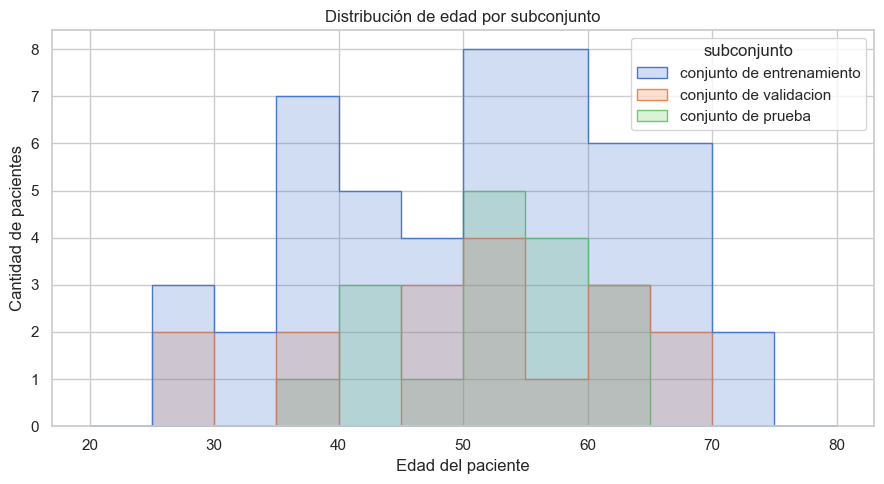

/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


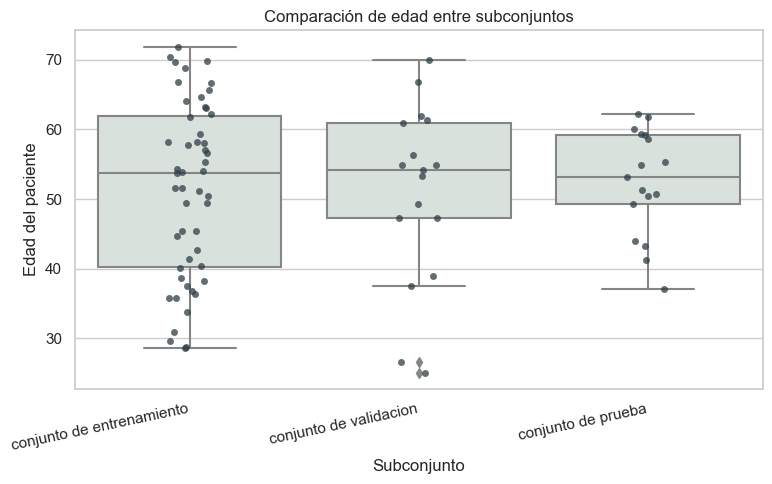

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(


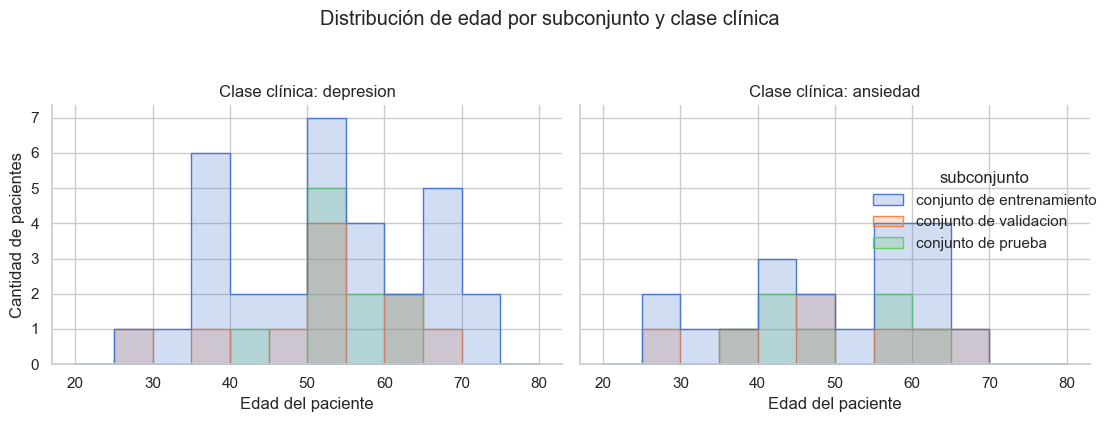

/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


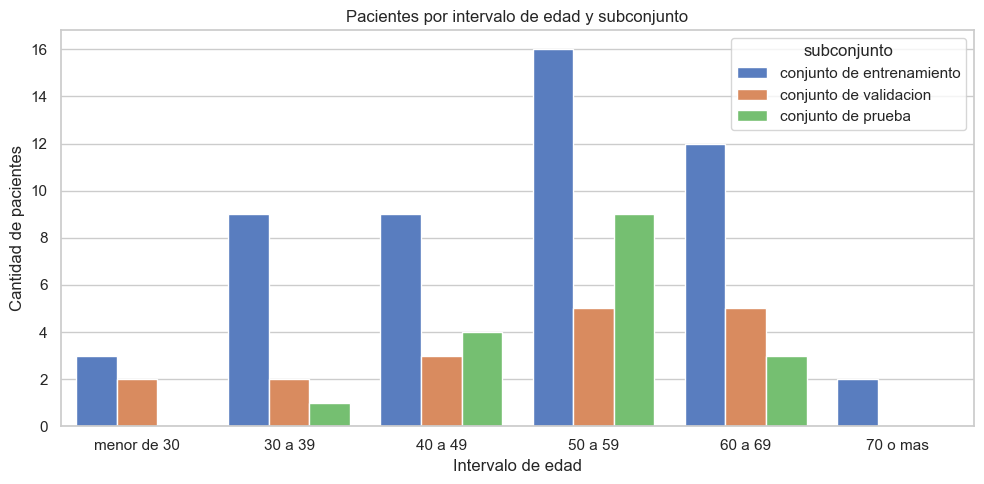

Figuras de edad generadas:
- histograma_edad_por_subconjunto: reports/eda_audit_20260619/figures/edad_histograma_por_subconjunto.png
- comparacion_edad_subconjuntos: reports/eda_audit_20260619/figures/edad_comparacion_subconjuntos_boxplot.png
- histograma_edad_por_subconjunto_y_clase: reports/eda_audit_20260619/figures/edad_histograma_por_subconjunto_y_clase.png
- pacientes_por_intervalo_edad_subconjunto: reports/eda_audit_20260619/figures/edad_pacientes_por_intervalo_subconjunto.png
Pacientes por intervalo de edad y subconjunto


,subconjunto,intervalo_de_edad,cantidad_de_pacientes
0,conjunto de entrenamiento,menor de 30,3
1,conjunto de entrenamiento,30 a 39,9
2,conjunto de entrenamiento,40 a 49,9
3,conjunto de entrenamiento,50 a 59,16
4,conjunto de entrenamiento,60 a 69,12
5,conjunto de entrenamiento,70 o mas,2
6,conjunto de validacion,menor de 30,2
7,conjunto de validacion,30 a 39,2
8,conjunto de validacion,40 a 49,3
9,conjunto de validacion,50 a 59,5


Pacientes por intervalo de edad, subconjunto y clase clínica


,subconjunto,clase_clinica,intervalo_de_edad,cantidad_de_pacientes
0,conjunto de entrenamiento,ansiedad,menor de 30,2
1,conjunto de entrenamiento,ansiedad,30 a 39,2
2,conjunto de entrenamiento,ansiedad,40 a 49,5
3,conjunto de entrenamiento,ansiedad,50 a 59,5
4,conjunto de entrenamiento,ansiedad,60 a 69,5
5,conjunto de entrenamiento,ansiedad,70 o mas,0
6,conjunto de entrenamiento,depresion,menor de 30,1
7,conjunto de entrenamiento,depresion,30 a 39,7
8,conjunto de entrenamiento,depresion,40 a 49,4
9,conjunto de entrenamiento,depresion,50 a 59,11


In [12]:
# Distribución etaria a nivel de paciente.
# Se usa la misma tabla `patient_metadata` definida en la sección anterior:
# una fila por paciente dentro de su subconjunto.
age_plot_data = patient_metadata.dropna(subset=['edad_en_consulta']).copy()
age_plot_data['subconjunto'] = pd.Categorical(
    age_plot_data['subconjunto'],
    categories=SUBSET_DISPLAY_ORDER,
    ordered=True,
)

age_bins = [0, 30, 40, 50, 60, 70, np.inf]
age_labels = ['menor de 30', '30 a 39', '40 a 49', '50 a 59', '60 a 69', '70 o mas']
age_plot_data['intervalo_de_edad'] = pd.cut(
    age_plot_data['edad_en_consulta'],
    bins=age_bins,
    labels=age_labels,
    right=False,
)

# Tabla 1: cantidad de pacientes por intervalo de edad y subconjunto.
age_interval_summary = (
    age_plot_data
    .groupby(['subconjunto', 'intervalo_de_edad'], observed=False)
    .size()
    .reset_index(name='cantidad_de_pacientes')
)
age_interval_summary['subconjunto'] = age_interval_summary['subconjunto'].astype(str)
age_interval_summary['intervalo_de_edad'] = pd.Categorical(
    age_interval_summary['intervalo_de_edad'],
    categories=age_labels,
    ordered=True,
)
age_interval_summary['_orden_subconjunto'] = age_interval_summary['subconjunto'].map(
    {name: idx for idx, name in enumerate(SUBSET_DISPLAY_ORDER)}
)
age_interval_summary = (
    age_interval_summary
    .sort_values(['_orden_subconjunto', 'intervalo_de_edad'])
    .drop(columns=['_orden_subconjunto'])
)

# Tabla 2: cantidad de pacientes por intervalo de edad, subconjunto y clase.
age_interval_class_summary = (
    age_plot_data
    .groupby(['subconjunto', 'clase_clinica' if 'clase_clinica' in age_plot_data.columns else 'etiqueta', 'intervalo_de_edad'], observed=False)
    .size()
    .reset_index(name='cantidad_de_pacientes')
)
if 'etiqueta' in age_interval_class_summary.columns:
    age_interval_class_summary = age_interval_class_summary.rename(columns={'etiqueta': 'clase_clinica'})
age_interval_class_summary['subconjunto'] = age_interval_class_summary['subconjunto'].astype(str)
age_interval_class_summary['intervalo_de_edad'] = pd.Categorical(
    age_interval_class_summary['intervalo_de_edad'],
    categories=age_labels,
    ordered=True,
)
age_interval_class_summary['_orden_subconjunto'] = age_interval_class_summary['subconjunto'].map(
    {name: idx for idx, name in enumerate(SUBSET_DISPLAY_ORDER)}
)
age_interval_class_summary['_orden_clase'] = age_interval_class_summary['clase_clinica'].map({'ansiedad': 0, 'depresion': 1})
age_interval_class_summary = (
    age_interval_class_summary
    .sort_values(['_orden_subconjunto', '_orden_clase', 'intervalo_de_edad'])
    .drop(columns=['_orden_subconjunto', '_orden_clase'])
)

# Archivos de figuras vinculables desde Markdown.
AGE_FIGURES = {
    'histograma_edad_por_subconjunto': FIGURES_DIR / 'edad_histograma_por_subconjunto.png',
    'comparacion_edad_subconjuntos': FIGURES_DIR / 'edad_comparacion_subconjuntos_boxplot.png',
    'histograma_edad_por_subconjunto_y_clase': FIGURES_DIR / 'edad_histograma_por_subconjunto_y_clase.png',
    'pacientes_por_intervalo_edad_subconjunto': FIGURES_DIR / 'edad_pacientes_por_intervalo_subconjunto.png',
}

# Figura 1: histograma completo por subconjunto.
plt.figure(figsize=(9, 5))
sns.histplot(
    data=age_plot_data,
    x='edad_en_consulta',
    hue='subconjunto',
    bins=np.arange(20, 81, 5),
    element='step',
    stat='count',
    common_norm=False,
)
plt.title('Distribución de edad por subconjunto')
plt.xlabel('Edad del paciente')
plt.ylabel('Cantidad de pacientes')
plt.tight_layout()
plt.savefig(AGE_FIGURES['histograma_edad_por_subconjunto'], dpi=180)
plt.show()

# Figura 2: comparación visual directa entre subconjuntos.
plt.figure(figsize=(8, 5))
sns.boxplot(data=age_plot_data, x='subconjunto', y='edad_en_consulta', color='#d8e2dc')
sns.stripplot(data=age_plot_data, x='subconjunto', y='edad_en_consulta', color='#2f3e46', size=5, alpha=0.75)
plt.title('Comparación de edad entre subconjuntos')
plt.xlabel('Subconjunto')
plt.ylabel('Edad del paciente')
plt.xticks(rotation=12, ha='right')
plt.tight_layout()
plt.savefig(AGE_FIGURES['comparacion_edad_subconjuntos'], dpi=180)
plt.show()

# Figura 3: distribución por subconjunto y clase clínica.
grid = sns.displot(
    data=age_plot_data,
    x='edad_en_consulta',
    hue='subconjunto',
    col='etiqueta',
    bins=np.arange(20, 81, 5),
    element='step',
    stat='count',
    common_norm=False,
    height=4,
    aspect=1.1,
)
grid.set_axis_labels('Edad del paciente', 'Cantidad de pacientes')
grid.set_titles('Clase clínica: {col_name}')
grid.fig.suptitle('Distribución de edad por subconjunto y clase clínica', y=1.05)
grid.fig.tight_layout()
grid.fig.savefig(AGE_FIGURES['histograma_edad_por_subconjunto_y_clase'], dpi=180, bbox_inches='tight')
plt.show()

# Figura 4: cantidad de pacientes por intervalos de edad.
plt.figure(figsize=(10, 5))
sns.barplot(
    data=age_interval_summary,
    x='intervalo_de_edad',
    y='cantidad_de_pacientes',
    hue='subconjunto',
)
plt.title('Pacientes por intervalo de edad y subconjunto')
plt.xlabel('Intervalo de edad')
plt.ylabel('Cantidad de pacientes')
plt.tight_layout()
plt.savefig(AGE_FIGURES['pacientes_por_intervalo_edad_subconjunto'], dpi=180)
plt.show()

print('Figuras de edad generadas:')
for name, path in AGE_FIGURES.items():
    print(f'- {name}: {path.relative_to(BASE_PATH)}')

print('Pacientes por intervalo de edad y subconjunto')
display(age_interval_summary)
print('Pacientes por intervalo de edad, subconjunto y clase clínica')
display(age_interval_class_summary)


## 13. Longitud, truncamiento y vocabulario por subconjunto

Se reportan palabras, tokens, cola superior de longitud y vocabulario filtrado. Esto permite evaluar si un subconjunto concentra notas más largas o más riesgo de truncamiento.

In [13]:
# Longitud y truncamiento.
text_length_rows = []
for subset_name, sub in enriched.groupby('subconjunto', sort=False):
    words = summarize_numeric(sub['cantidad_palabras'])
    tokens = summarize_numeric(sub['cantidad_tokens'])
    text_length_rows.append({
        'subconjunto': subset_name,
        'media_de_palabras_por_nota': words['media'],
        'desviacion_estandar_de_palabras_por_nota': words['desviacion_estandar'],
        'media_de_tokens_por_nota': tokens['media'],
        'desviacion_estandar_de_tokens_por_nota': tokens['desviacion_estandar'],
        'mediana_de_tokens_por_nota': tokens['mediana'],
        'percentil_95_de_tokens_por_nota': tokens['percentil_95'],
        'cantidad_de_notas_con_mas_de_512_tokens': int(sub['supera_512_tokens'].sum()),
        'porcentaje_de_notas_con_mas_de_512_tokens': float(sub['supera_512_tokens'].mean() * 100),
        'tokens_potencialmente_truncados_sobre_512': int(sub['tokens_potencialmente_truncados_sobre_512'].sum()),
    })
text_length_summary = subset_row_order(pd.DataFrame(text_length_rows))

# Vocabulario filtrado.
vocab_rows = []
for subset_name, sub in [('Total', enriched), *list(enriched.groupby('subconjunto', sort=False))]:
    counter = Counter()
    for text in sub['texto']:
        counter.update(tokenize_words_for_vocab(text))
    vocab_rows.append({
        'grupo_de_notas': subset_name,
        'cantidad_de_notas': int(len(sub)),
        'tamano_del_vocabulario_filtrado': int(len(counter)),
        'cantidad_de_tokens_filtrados': int(sum(counter.values())),
    })
vocabulary_summary = pd.DataFrame(vocab_rows)

# Solapamiento entre subconjuntos usando top 100 términos frecuentes.
subset_token_sets = {}
for subset_name, sub in enriched.groupby('subconjunto', sort=False):
    counter = Counter()
    for text in sub['texto']:
        counter.update(tokenize_words_for_vocab(text))
    subset_token_sets[subset_name] = {term for term, _ in counter.most_common(100)}

overlap_rows = []
for i, left in enumerate(SUBSET_DISPLAY_ORDER):
    for right in SUBSET_DISPLAY_ORDER[i + 1:]:
        union = subset_token_sets[left] | subset_token_sets[right]
        intersection = subset_token_sets[left] & subset_token_sets[right]
        overlap_rows.append({
            'comparacion_entre_subconjuntos': f'{left} vs {right}',
            'jaccard_entre_los_100_terminos_mas_frecuentes': float(len(intersection) / len(union)) if union else np.nan,
        })
vocabulary_overlap = pd.DataFrame(overlap_rows)

print('Longitud y truncamiento por subconjunto')
display(text_length_summary.round(2))
print('Vocabulario filtrado')
display(vocabulary_summary)
print('Solapamiento léxico')
display(vocabulary_overlap.round(3))

Longitud y truncamiento por subconjunto


,subconjunto,media_de_palabras_por_nota,desviacion_estandar_de_palabras_por_nota,media_de_tokens_por_nota,desviacion_estandar_de_tokens_por_nota,mediana_de_tokens_por_nota,percentil_95_de_tokens_por_nota,cantidad_de_notas_con_mas_de_512_tokens,porcentaje_de_notas_con_mas_de_512_tokens,tokens_potencialmente_truncados_sobre_512
0,conjunto de entrenamiento,234.7,261.18,361.03,426.36,241.0,1087.2,225,20.33,101419
1,conjunto de validacion,202.8,217.62,318.71,386.72,200.0,971.5,59,17.20,26474
2,conjunto de prueba,218.6,221.25,353.47,375.34,246.0,1020.0,82,21.30,31094


Vocabulario filtrado


,grupo_de_notas,cantidad_de_notas,tamano_del_vocabulario_filtrado,cantidad_de_tokens_filtrados
0,Total,1835,7723,202255
1,conjunto de entrenamiento,1107,5939,127554
2,conjunto de validacion,343,2559,34464
3,conjunto de prueba,385,3052,40237


Solapamiento léxico


,comparacion_entre_subconjuntos,jaccard_entre_los_100_terminos_mas_frecuentes
0,conjunto de entrenamiento vs conjunto de validacion,0.600
1,conjunto de entrenamiento vs conjunto de prueba,0.575
2,conjunto de validacion vs conjunto de prueba,0.481


## 14. Impacto del denoising

El denoising define qué notas entran al universo modelado. Por eso se reporta la retención por subconjunto y por clase clínica.

In [14]:
denoising_rows = []
for group_cols in [['subconjunto'], ['subconjunto', 'etiqueta']]:
    for key, sub in clinical_with_split.groupby(group_cols, dropna=False, sort=False):
        if not isinstance(key, tuple):
            key = (key,)
        row = {col: val for col, val in zip(group_cols, key)}
        retained = sub['retenida_por_denoising']
        excluded = ~retained
        row.update({
            'agrupacion': ' + '.join(group_cols),
            'notas_en_base_limpia_antes_del_denoising': int(len(sub)),
            'notas_retenidas_en_dataset_denoised': int(retained.sum()),
            'notas_excluidas_por_denoising': int(excluded.sum()),
            'porcentaje_de_notas_retenidas': float(retained.mean() * 100) if len(sub) else np.nan,
            'mediana_de_caracteres_en_notas_excluidas': summarize_numeric(sub.loc[excluded, 'cantidad_caracteres'])['mediana'],
            'mediana_de_palabras_en_notas_excluidas': summarize_numeric(sub.loc[excluded, 'cantidad_palabras'])['mediana'],
        })
        denoising_rows.append(row)

denoising_summary = subset_row_order(pd.DataFrame(denoising_rows))
display(denoising_summary.round(2))

,subconjunto,agrupacion,notas_en_base_limpia_antes_del_denoising,notas_retenidas_en_dataset_denoised,notas_excluidas_por_denoising,porcentaje_de_notas_retenidas,mediana_de_caracteres_en_notas_excluidas,mediana_de_palabras_en_notas_excluidas,etiqueta
0,conjunto de entrenamiento,subconjunto,1911,1107,804,57.93,38.0,5.0,NaN
3,conjunto de entrenamiento,subconjunto + etiqueta,578,358,220,61.94,41.0,5.0,ansiedad
6,conjunto de entrenamiento,subconjunto + etiqueta,1333,749,584,56.19,37.0,5.0,depresion
1,conjunto de validacion,subconjunto,595,343,252,57.65,40.0,5.0,NaN
4,conjunto de validacion,subconjunto + etiqueta,186,100,86,53.76,38.5,5.0,ansiedad
7,conjunto de validacion,subconjunto + etiqueta,409,243,166,59.41,40.5,5.0,depresion
2,conjunto de prueba,subconjunto,637,385,252,60.44,46.0,6.0,NaN
5,conjunto de prueba,subconjunto + etiqueta,161,98,63,60.87,53.0,7.0,ansiedad
8,conjunto de prueba,subconjunto + etiqueta,476,287,189,60.29,43.0,6.0,depresion


## 15. Figuras complementarias para el reporte

Estas figuras resumen visualmente las diferencias descriptivas revisadas en las tablas. Se generan dentro del notebook para que el reporte Markdown no dependa de recursos externos ni de scripts auxiliares.


In [15]:
# Figuras complementarias vinculables desde el reporte Markdown.
REPORT_FIGURES = {
    'notas_por_paciente_por_subconjunto_clase': FIGURES_DIR / 'notas_por_paciente_por_subconjunto_clase.png',
    'sexo_pacientes_por_subconjunto': FIGURES_DIR / 'sexo_pacientes_por_subconjunto.png',
    'edad_histograma_por_subconjunto': AGE_FIGURES['histograma_edad_por_subconjunto'],
    'edad_comparacion_subconjuntos': AGE_FIGURES['comparacion_edad_subconjuntos'],
    'edad_histograma_por_subconjunto_y_clase': AGE_FIGURES['histograma_edad_por_subconjunto_y_clase'],
    'edad_pacientes_por_intervalo_subconjunto': AGE_FIGURES['pacientes_por_intervalo_edad_subconjunto'],
    'tokens_por_nota_por_subconjunto': FIGURES_DIR / 'tokens_por_nota_por_subconjunto.png',
    'truncamiento_512_por_subconjunto': FIGURES_DIR / 'truncamiento_512_por_subconjunto.png',
    'vocabulario_filtrado_por_subconjunto': FIGURES_DIR / 'vocabulario_filtrado_por_subconjunto.png',
    'solapamiento_lexico_por_subconjunto': FIGURES_DIR / 'solapamiento_lexico_por_subconjunto.png',
    'retencion_denoising_por_subconjunto': FIGURES_DIR / 'retencion_denoising_por_subconjunto.png',
}

# Notas por paciente, estratificadas por clase clinica.
patient_class = (
    enriched.groupby(['subconjunto', 'patient_id'], as_index=False)
    .agg(clase_clinica=('etiqueta', 'first'))
)
notes_patient_plot = notes_per_patient.merge(patient_class, on=['subconjunto', 'patient_id'], how='left')
notes_patient_plot['subconjunto'] = pd.Categorical(notes_patient_plot['subconjunto'], categories=SUBSET_DISPLAY_ORDER, ordered=True)
plt.figure(figsize=(9, 5))
sns.boxplot(data=notes_patient_plot, x='subconjunto', y='cantidad_de_notas', hue='clase_clinica', palette='Set2')
sns.stripplot(data=notes_patient_plot, x='subconjunto', y='cantidad_de_notas', color='#2f3e46', size=3.5, alpha=0.55, dodge=True)
plt.title('Notas por paciente segun subconjunto y clase clinica')
plt.xlabel('Subconjunto')
plt.ylabel('Cantidad de notas por paciente')
plt.xticks(rotation=12, ha='right')
plt.legend(title='Clase clinica', loc='upper right')
plt.tight_layout()
plt.savefig(REPORT_FIGURES['notas_por_paciente_por_subconjunto_clase'], dpi=180)
plt.close()

# Sexo a nivel de paciente.
sex_plot_data = (
    patient_metadata.groupby(['subconjunto', 'sexo_normalizado'], observed=False)
    .size()
    .reset_index(name='cantidad_de_pacientes')
)
sex_plot_data['subconjunto'] = pd.Categorical(sex_plot_data['subconjunto'], categories=SUBSET_DISPLAY_ORDER, ordered=True)
plt.figure(figsize=(8, 5))
sns.barplot(data=sex_plot_data, x='subconjunto', y='cantidad_de_pacientes', hue='sexo_normalizado', palette='Set2')
plt.title('Distribucion de sexo a nivel de paciente por subconjunto')
plt.xlabel('Subconjunto')
plt.ylabel('Cantidad de pacientes')
plt.xticks(rotation=12, ha='right')
plt.legend(title='Sexo normalizado')
plt.tight_layout()
plt.savefig(REPORT_FIGURES['sexo_pacientes_por_subconjunto'], dpi=180)
plt.close()

# Distribucion de tokens por nota. Se recorta visualmente en p99 para que la cola extrema no oculte el cuerpo de la distribucion.
token_cap = enriched['cantidad_tokens'].quantile(0.99)
token_plot_data = enriched.copy()
token_plot_data['tokens_para_grafico'] = token_plot_data['cantidad_tokens'].clip(upper=token_cap)
token_plot_data['subconjunto'] = pd.Categorical(token_plot_data['subconjunto'], categories=SUBSET_DISPLAY_ORDER, ordered=True)
plt.figure(figsize=(9, 5))
sns.histplot(
    data=token_plot_data,
    x='tokens_para_grafico',
    hue='subconjunto',
    bins=40,
    element='step',
    stat='count',
    common_norm=False,
)
plt.axvline(MAX_TOKENS, color='#b23a48', linestyle='--', linewidth=1.5, label='Limite 512 tokens')
plt.title('Distribucion de tokens por nota y subconjunto')
plt.xlabel('Cantidad de tokens por nota, recortada visualmente en p99')
plt.ylabel('Cantidad de notas')
plt.tight_layout()
plt.savefig(REPORT_FIGURES['tokens_por_nota_por_subconjunto'], dpi=180)
plt.close()

# Truncamiento potencial con limite de 512 tokens.
trunc_plot_data = text_length_summary[['subconjunto', 'porcentaje_de_notas_con_mas_de_512_tokens']].copy()
trunc_plot_data['subconjunto'] = pd.Categorical(trunc_plot_data['subconjunto'], categories=SUBSET_DISPLAY_ORDER, ordered=True)
plt.figure(figsize=(7.5, 5))
sns.barplot(data=trunc_plot_data, x='subconjunto', y='porcentaje_de_notas_con_mas_de_512_tokens', color='#74a9cf')
plt.title('Notas con mas de 512 tokens por subconjunto')
plt.xlabel('Subconjunto')
plt.ylabel('Porcentaje de notas')
plt.xticks(rotation=12, ha='right')
plt.tight_layout()
plt.savefig(REPORT_FIGURES['truncamiento_512_por_subconjunto'], dpi=180)
plt.close()

# Tamano de vocabulario filtrado.
vocab_plot_data = vocabulary_summary.copy()
vocab_plot_data['grupo_de_notas'] = pd.Categorical(vocab_plot_data['grupo_de_notas'], categories=['Total', *SUBSET_DISPLAY_ORDER], ordered=True)
plt.figure(figsize=(8, 5))
sns.barplot(data=vocab_plot_data, x='grupo_de_notas', y='tamano_del_vocabulario_filtrado', color='#8ab17d')
plt.title('Tamano del vocabulario filtrado')
plt.xlabel('Grupo de notas')
plt.ylabel('Cantidad de terminos')
plt.xticks(rotation=12, ha='right')
plt.tight_layout()
plt.savefig(REPORT_FIGURES['vocabulario_filtrado_por_subconjunto'], dpi=180)
plt.close()

# Solapamiento lexico entre subconjuntos.
plt.figure(figsize=(8, 5))
sns.barplot(data=vocabulary_overlap, y='comparacion_entre_subconjuntos', x='jaccard_entre_los_100_terminos_mas_frecuentes', color='#f4a261')
plt.title('Solapamiento lexico entre subconjuntos')
plt.xlabel('Jaccard entre los 100 terminos mas frecuentes')
plt.ylabel('Comparacion')
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(REPORT_FIGURES['solapamiento_lexico_por_subconjunto'], dpi=180)
plt.close()

# Retencion despues del denoising.
denoising_subset = denoising_summary[denoising_summary['agrupacion'] == 'subconjunto']
denoising_subset_plot = denoising_subset.copy()
denoising_subset_plot['subconjunto'] = pd.Categorical(denoising_subset_plot['subconjunto'], categories=SUBSET_DISPLAY_ORDER, ordered=True)
plt.figure(figsize=(7.5, 5))
sns.barplot(data=denoising_subset_plot, x='subconjunto', y='porcentaje_de_notas_retenidas', color='#9d8189')
plt.title('Retencion de notas despues del denoising')
plt.xlabel('Subconjunto')
plt.ylabel('Porcentaje de notas retenidas')
plt.ylim(0, 100)
plt.xticks(rotation=12, ha='right')
plt.tight_layout()
plt.savefig(REPORT_FIGURES['retencion_denoising_por_subconjunto'], dpi=180)
plt.close()

pd.DataFrame({'figura': list(REPORT_FIGURES.keys()), 'archivo': [str(path.relative_to(EDA_AUDIT_DIR)) for path in REPORT_FIGURES.values()]})


/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-pack

,figura,archivo
0,notas_por_paciente_por_subconjunto_clase,figures/notas_por_paciente_por_subconjunto_clase.png
1,sexo_pacientes_por_subconjunto,figures/sexo_pacientes_por_subconjunto.png
2,edad_histograma_por_subconjunto,figures/edad_histograma_por_subconjunto.png
3,edad_comparacion_subconjuntos,figures/edad_comparacion_subconjuntos_boxplot.png
4,edad_histograma_por_subconjunto_y_clase,figures/edad_histograma_por_subconjunto_y_clase.png
5,edad_pacientes_por_intervalo_subconjunto,figures/edad_pacientes_por_intervalo_subconjunto.png
6,tokens_por_nota_por_subconjunto,figures/tokens_por_nota_por_subconjunto.png
7,truncamiento_512_por_subconjunto,figures/truncamiento_512_por_subconjunto.png
8,vocabulario_filtrado_por_subconjunto,figures/vocabulario_filtrado_por_subconjunto.png
9,solapamiento_lexico_por_subconjunto,figures/solapamiento_lexico_por_subconjunto.png


## 16. Exportación de tablas y reporte Markdown

Esta sección escribe las tablas CSV, el reporte Markdown y el manifiesto de ejecución.

In [16]:
outputs = {
    'eda_universos.csv': global_universe,
    'eda_resumen_textual_global.csv': global_text_summary,
    'eda_distribucion_clases_global.csv': global_class,
    'eda_resumen_por_subconjunto.csv': subset_summary,
    'eda_distribucion_clases_por_subconjunto.csv': class_distribution,
    'eda_notas_por_paciente_por_subconjunto.csv': notes_per_patient_summary,
    'eda_sexo_edad_por_subconjunto.csv': demographic_summary,
    'eda_pacientes_por_intervalo_edad_subconjunto.csv': age_interval_summary,
    'eda_pacientes_por_intervalo_edad_subconjunto_clase.csv': age_interval_class_summary,
    'eda_longitud_por_subconjunto.csv': text_length_summary,
    'eda_vocabulario_por_subconjunto.csv': vocabulary_summary,
    'eda_solapamiento_lexico_por_subconjunto.csv': vocabulary_overlap,
    'eda_denoising_por_subconjunto.csv': denoising_summary,
    'eda_integridad_subconjuntos.csv': integrity_summary,
}
for filename, table in outputs.items():
    table.to_csv(TABLES_DIR / filename, index=False)

universe_rows = [[r['universo_de_datos'], fmt_es(r['cantidad_de_notas'], 0), r['uso_en_el_reporte']] for _, r in global_universe.iterrows()]
global_text_rows = [[r['estadistico_descriptivo'], fmt_es(r['cantidad_de_palabras_por_nota']), fmt_es(r['cantidad_de_tokens_por_nota'])] for _, r in global_text_summary.iterrows()]
global_class_rows = [[r['clase_clinica'], fmt_es(r['cantidad_de_pacientes'], 0), fmt_es(r['cantidad_de_notas'], 0), pct_es(r['porcentaje_de_notas'])] for _, r in global_class.iterrows()]
global_class_rows.append(['Total', fmt_es(enriched['patient_id'].nunique(), 0), fmt_es(len(enriched), 0), '100,00%'])
subset_size_rows = [[r['subconjunto'], fmt_es(r['cantidad_de_pacientes'], 0), fmt_es(r['cantidad_de_notas'], 0), fmt_es(r['media_de_tokens_por_nota']), pct_es(r['porcentaje_de_notas_con_mas_de_512_tokens'])] for _, r in subset_summary.iterrows()]
class_subset_rows = [[r['subconjunto'], r['clase_clinica'], fmt_es(r['cantidad_de_pacientes'], 0), fmt_es(r['cantidad_de_notas'], 0), pct_es(r['porcentaje_de_notas_del_subconjunto'])] for _, r in class_distribution.iterrows()]
notes_patient_rows = [[r['subconjunto'], fmt_es(r['media_de_notas_por_paciente']), fmt_es(r['desviacion_estandar_de_notas_por_paciente']), fmt_es(r['mediana_de_notas_por_paciente']), r['rango_minimo_maximo']] for _, r in notes_per_patient_summary.iterrows()]
sex_rows = [[r['subconjunto'], fmt_es(r['cantidad_de_pacientes'], 0), fmt_es(r['cantidad_de_mujeres'], 0), fmt_es(r['cantidad_de_hombres'], 0), fmt_es(r['cantidad_con_sexo_faltante_o_no_informado'], 0)] for _, r in demographic_summary.iterrows()]
age_rows = [[r['subconjunto'], fmt_es(r['media_de_edad']), fmt_es(r['desviacion_estandar_de_edad']), fmt_es(r['mediana_de_edad']), r['rango_minimo_maximo_de_edad']] for _, r in demographic_summary.iterrows()]
age_interval_rows = [[r['subconjunto'], str(r['intervalo_de_edad']), fmt_es(r['cantidad_de_pacientes'], 0)] for _, r in age_interval_summary.iterrows()]
age_interval_class_rows = [[r['subconjunto'], r['clase_clinica'], str(r['intervalo_de_edad']), fmt_es(r['cantidad_de_pacientes'], 0)] for _, r in age_interval_class_summary.iterrows()]
length_rows = [[r['subconjunto'], fmt_es(r['media_de_palabras_por_nota']), fmt_es(r['desviacion_estandar_de_palabras_por_nota']), fmt_es(r['media_de_tokens_por_nota']), fmt_es(r['desviacion_estandar_de_tokens_por_nota'])] for _, r in text_length_summary.iterrows()]
trunc_rows = [[r['subconjunto'], fmt_es(r['cantidad_de_notas_con_mas_de_512_tokens'], 0), pct_es(r['porcentaje_de_notas_con_mas_de_512_tokens']), fmt_es(r['percentil_95_de_tokens_por_nota']), fmt_es(r['tokens_potencialmente_truncados_sobre_512'], 0)] for _, r in text_length_summary.iterrows()]
vocab_rows_report = [[r['grupo_de_notas'], fmt_es(r['cantidad_de_notas'], 0), fmt_es(r['tamano_del_vocabulario_filtrado'], 0), fmt_es(r['cantidad_de_tokens_filtrados'], 0)] for _, r in vocabulary_summary.iterrows()]
overlap_report_rows = [[r['comparacion_entre_subconjuntos'], fmt_es(r['jaccard_entre_los_100_terminos_mas_frecuentes'], 3)] for _, r in vocabulary_overlap.iterrows()]
denoising_subset = denoising_summary[denoising_summary['agrupacion'] == 'subconjunto']
denoising_rows_report = [[r['subconjunto'], fmt_es(r['notas_en_base_limpia_antes_del_denoising'], 0), fmt_es(r['notas_retenidas_en_dataset_denoised'], 0), fmt_es(r['notas_excluidas_por_denoising'], 0), pct_es(r['porcentaje_de_notas_retenidas'])] for _, r in denoising_subset.iterrows()]
denoising_class_rows_report = [[r['subconjunto'], r['etiqueta'], fmt_es(r['notas_en_base_limpia_antes_del_denoising'], 0), fmt_es(r['notas_retenidas_en_dataset_denoised'], 0), pct_es(r['porcentaje_de_notas_retenidas'])] for _, r in denoising_summary[denoising_summary['agrupacion'] == 'subconjunto + etiqueta'].iterrows()]

train_anx = class_distribution[(class_distribution['subconjunto'] == SUBSET_LABELS['train']) & (class_distribution['clase_clinica'] == 'ansiedad')]['porcentaje_de_notas_del_subconjunto'].iloc[0]
dev_anx = class_distribution[(class_distribution['subconjunto'] == SUBSET_LABELS['dev']) & (class_distribution['clase_clinica'] == 'ansiedad')]['porcentaje_de_notas_del_subconjunto'].iloc[0]
test_anx = class_distribution[(class_distribution['subconjunto'] == SUBSET_LABELS['test']) & (class_distribution['clase_clinica'] == 'ansiedad')]['porcentaje_de_notas_del_subconjunto'].iloc[0]
retention_min = denoising_subset['porcentaje_de_notas_retenidas'].min()
retention_max = denoising_subset['porcentaje_de_notas_retenidas'].max()
trunc_min = text_length_summary['porcentaje_de_notas_con_mas_de_512_tokens'].min()
trunc_max = text_length_summary['porcentaje_de_notas_con_mas_de_512_tokens'].max()

report = f"""# Reporte EDA del corpus IPS por subconjuntos

Este reporte resume el EDA ampliado del corpus IPS. El reporte mantiene las estadisticas generales, pero pone el foco en la comparacion por subconjunto: conjunto de entrenamiento, conjunto de validacion y conjunto de prueba.

El analisis principal usa `dataset_denoised`, porque ese es el universo de notas que conserva senal clinica util y que fue usado por el proyecto. El raw se usa solo para recuperar metadatos descriptivos, especialmente sexo, fecha de nacimiento y fecha de consulta. No se imprimen textos clinicos crudos ni identificadores originales.

## 1. Universo analizado

**Tabla 1. Universos considerados en el EDA**

{md_table(['Universo de datos', 'Cantidad de notas', 'Uso en este reporte'], universe_rows)}

Lectura: el denoising no elimina pacientes completos. Los 90 pacientes del corpus modelado siguen presentes; lo que cambia es la cantidad de notas disponibles por paciente.

## 2. Resumen global

**Tabla 2. Longitud textual global del corpus denoised**

{md_table(['Estadistico descriptivo', 'Cantidad de palabras por nota', 'Cantidad de tokens por nota'], global_text_rows)}

**Tabla 3. Distribucion global de clases en el corpus denoised**

{md_table(['Clase clinica', 'Cantidad de pacientes', 'Cantidad de notas', 'Porcentaje de notas'], global_class_rows)}

Lectura: el corpus global esta desbalanceado hacia depresion. Esta lectura general es importante, pero no alcanza: por eso se revisa la distribucion por subconjunto.

## 3. Comparacion general por subconjunto

**Tabla 4. Tamano y longitud general por subconjunto**

{md_table(['Subconjunto', 'Cantidad de pacientes', 'Cantidad de notas', 'Media de tokens por nota', 'Porcentaje de notas con mas de 512 tokens'], subset_size_rows)}

**Tabla 5. Distribucion de clases por subconjunto**

{md_table(['Subconjunto', 'Clase clinica', 'Cantidad de pacientes', 'Cantidad de notas', 'Porcentaje de notas del subconjunto'], class_subset_rows)}

Lectura: ansiedad representa {pct_es(train_anx)} de las notas del conjunto de entrenamiento, {pct_es(dev_anx)} del conjunto de validacion y {pct_es(test_anx)} del conjunto de prueba. La diferencia no invalida los subconjuntos, pero muestra que la clase ansiedad queda relativamente menos representada en el conjunto de prueba.

## 4. Pacientes, sexo y edad por subconjunto

**Tabla 6. Distribucion de notas por paciente segun subconjunto**

{md_table(['Subconjunto', 'Media de notas por paciente', 'Desviacion estandar de notas por paciente', 'Mediana de notas por paciente', 'Rango minimo-maximo'], notes_patient_rows)}

**Figura 1. Notas por paciente segun subconjunto y clase clinica**

![Notas por paciente segun subconjunto y clase clinica](figures/notas_por_paciente_por_subconjunto_clase.png)

**Tabla 7. Distribucion de sexo a nivel de paciente por subconjunto**

{md_table(['Subconjunto', 'Cantidad de pacientes', 'Cantidad de mujeres', 'Cantidad de hombres', 'Cantidad con sexo faltante'], sex_rows)}

**Figura 2. Distribucion de sexo a nivel de paciente por subconjunto**

![Distribucion de sexo a nivel de paciente por subconjunto](figures/sexo_pacientes_por_subconjunto.png)

**Tabla 8. Distribucion de edad a nivel de paciente por subconjunto**

{md_table(['Subconjunto', 'Media de edad', 'Desviacion estandar de edad', 'Mediana de edad', 'Rango minimo-maximo de edad'], age_rows)}

Lectura: los subconjuntos tienen edades medias similares. Predominan mujeres en los tres subconjuntos. La cantidad de pacientes por subconjunto es menor en validacion y prueba, por lo que cualquier diferencia demografica debe leerse con cautela.

**Tabla 9. Cantidad de pacientes por intervalo de edad y subconjunto**

{md_table(['Subconjunto', 'Intervalo de edad', 'Cantidad de pacientes'], age_interval_rows)}

**Tabla 10. Cantidad de pacientes por intervalo de edad, subconjunto y clase clinica**

{md_table(['Subconjunto', 'Clase clinica', 'Intervalo de edad', 'Cantidad de pacientes'], age_interval_class_rows)}

**Figura 3. Histograma de edad por subconjunto**

![Histograma de edad por subconjunto](figures/edad_histograma_por_subconjunto.png)

**Figura 4. Comparacion visual de edad entre subconjuntos**

![Comparacion visual de edad entre subconjuntos](figures/edad_comparacion_subconjuntos_boxplot.png)

**Figura 5. Histograma de edad por subconjunto y clase clinica**

![Histograma de edad por subconjunto y clase clinica](figures/edad_histograma_por_subconjunto_y_clase.png)

**Figura 6. Pacientes por intervalo de edad y subconjunto**

![Pacientes por intervalo de edad y subconjunto](figures/edad_pacientes_por_intervalo_subconjunto.png)

Lectura adicional: el conjunto de prueba no contiene pacientes menores de 30 anos en esta muestra y su rango comienza en edades mas altas que entrenamiento y validacion. Esto no invalida el subconjunto, pero si debe quedar documentado como diferencia descriptiva relevante para interpretar resultados.

## 5. Longitud, truncamiento y vocabulario por subconjunto

**Tabla 11. Longitud textual por subconjunto**

{md_table(['Subconjunto', 'Media de palabras por nota', 'Desviacion estandar de palabras por nota', 'Media de tokens por nota', 'Desviacion estandar de tokens por nota'], length_rows)}

**Figura 7. Distribucion de tokens por nota y subconjunto**

![Distribucion de tokens por nota y subconjunto](figures/tokens_por_nota_por_subconjunto.png)

**Tabla 12. Truncamiento potencial por subconjunto con limite de 512 tokens**

{md_table(['Subconjunto', 'Notas con mas de 512 tokens', 'Porcentaje de notas con mas de 512 tokens', 'Percentil 95 de tokens por nota', 'Tokens potencialmente truncados sobre 512'], trunc_rows)}

**Figura 8. Porcentaje de notas con mas de 512 tokens por subconjunto**

![Porcentaje de notas con mas de 512 tokens por subconjunto](figures/truncamiento_512_por_subconjunto.png)

**Tabla 13. Vocabulario filtrado por subconjunto**

{md_table(['Grupo de notas', 'Cantidad de notas', 'Tamano del vocabulario filtrado', 'Cantidad de tokens filtrados'], vocab_rows_report)}

**Figura 9. Tamano del vocabulario filtrado por grupo de notas**

![Tamano del vocabulario filtrado por grupo de notas](figures/vocabulario_filtrado_por_subconjunto.png)

**Tabla 14. Solapamiento lexico entre subconjuntos**

{md_table(['Comparacion entre subconjuntos', 'Jaccard entre los 100 terminos mas frecuentes'], overlap_report_rows)}

**Figura 10. Solapamiento lexico entre subconjuntos**

![Solapamiento lexico entre subconjuntos](figures/solapamiento_lexico_por_subconjunto.png)

Lectura: el truncamiento potencial se mantiene entre {pct_es(trunc_min)} y {pct_es(trunc_max)} segun subconjunto. No parece ser un problema exclusivo de un subconjunto, sino una caracteristica global de cola larga textual. El vocabulario es mayor en el conjunto de entrenamiento porque contiene mas notas.

## 6. Impacto del denoising por subconjunto

El criterio operativo fue `has_clinical_signal=0`: despues de limpiar formato/plantilla y aplicar reglas de aseveracion, la nota no conserva senal clinica util para la tarea diferencial.

**Tabla 15. Retencion de notas por denoising segun subconjunto**

{md_table(['Subconjunto', 'Notas en base limpia antes del denoising', 'Notas retenidas en dataset denoised', 'Notas excluidas por denoising', 'Porcentaje de notas retenidas'], denoising_rows_report)}

**Figura 11. Retencion de notas despues del denoising por subconjunto**

![Retencion de notas despues del denoising por subconjunto](figures/retencion_denoising_por_subconjunto.png)

**Tabla 16. Retencion de notas por denoising segun subconjunto y clase clinica**

{md_table(['Subconjunto', 'Clase clinica', 'Notas en base limpia antes del denoising', 'Notas retenidas en dataset denoised', 'Porcentaje de notas retenidas'], denoising_class_rows_report)}

Lectura: la retencion por denoising se mueve entre {pct_es(retention_min)} y {pct_es(retention_max)} segun subconjunto. La diferencia es pequena frente al impacto global del filtro, que elimina una fraccion importante de notas breves o sin fenomenologia suficiente.

## 7. Conclusiones para discutir

- El EDA por subconjunto confirma que la separacion por paciente se mantiene: no hay pacientes compartidos entre subconjuntos.
- La clase depresion es mayoritaria en todos los subconjuntos; ansiedad queda menos representada en el conjunto de prueba.
- Sexo y edad son comparables en terminos generales, con predominio femenino y edades medias similares; el conjunto de prueba empieza en edades mas altas y no contiene pacientes menores de 30 anos.
- La longitud textual y el truncamiento muestran cola larga en todos los subconjuntos; no es un problema aislado de un unico subconjunto.
- El denoising tiene impacto fuerte sobre el universo de notas, pero la retencion por subconjunto es parecida.

En sintesis: el corpus no muestra una falla evidente de estratificacion, pero si presenta diferencias descriptivas que deben quedar documentadas antes de interpretar resultados: menor proporcion relativa de ansiedad en prueba, heterogeneidad longitudinal por paciente, cola larga textual e impacto del denoising.
"""

(EDA_AUDIT_DIR / 'reporte_auditoria_eda.md').write_text(report, encoding='utf-8')

manifest = {
    'run_timestamp': datetime.now().isoformat(timespec='seconds'),
    'producer': 'notebooks/pipeline/01_datos_eda_limpieza.ipynb',
    'note': 'EDA generado de forma autocontenida dentro del notebook; no invoca scripts externos.',
    'outputs': {
        'tables': sorted(outputs.keys()),
        'reports': ['reporte_auditoria_eda.md'],
        'figures': [path.name for path in REPORT_FIGURES.values()],
    },
    'subset_integrity': integrity_summary.to_dict(orient='records'),
}
(EDA_AUDIT_DIR / 'execution_manifest.json').write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding='utf-8')

print('Tablas EDA exportadas:', len(outputs))
print(f'Reporte EDA: {EDA_AUDIT_DIR / "reporte_auditoria_eda.md"}')


Tablas EDA exportadas: 14
Reporte EDA: /Users/manuelnunez/Projects/psych-phenotyping-paraguay/reports/eda_audit_20260619/reporte_auditoria_eda.md


## 17. Validaciones finales

La última celda verifica que las salidas principales existan, que las tablas del reporte sigan siendo aptas para PDF y que el EDA no dependa de scripts externos.

In [17]:
expected_outputs = [
    EDA_AUDIT_DIR / 'reporte_auditoria_eda.md',
    EDA_AUDIT_DIR / 'execution_manifest.json',
    *[TABLES_DIR / filename for filename in outputs],
    *REPORT_FIGURES.values(),
]
missing_outputs = [str(path.relative_to(BASE_PATH)) for path in expected_outputs if not path.exists()]
if missing_outputs:
    raise FileNotFoundError(f'Faltan salidas esperadas: {missing_outputs}')

report_text = (EDA_AUDIT_DIR / 'reporte_auditoria_eda.md').read_text(encoding='utf-8')
max_table_columns = 0
for line in report_text.splitlines():
    if line.startswith('|'):
        max_table_columns = max(max_table_columns, line.count('|') - 1)

if max_table_columns > 5:
    raise ValueError(f'Hay tablas con demasiadas columnas para PDF: {max_table_columns}')

print('Validaciones finales correctas.')
print(f'Salidas verificadas: {len(expected_outputs)}')
print(f'Máximo de columnas en tablas del reporte: {max_table_columns}')
print('El EDA se genera desde este notebook, sin scripts externos.')


Validaciones finales correctas.
Salidas verificadas: 27
Máximo de columnas en tablas del reporte: 5
El EDA se genera desde este notebook, sin scripts externos.
